# Live paper-trading monitor
Runs the cross-confirmed basket paper trader each closed 1h bar and shows a **self-updating
dashboard**: paper-equity curve, current net position, exposure, and the last decisions.
No real orders - it reuses `paper_trader.py` (logging only).

Run the monitor cell; it updates immediately (latest closed bar) then refreshes every hour.
Press the stop button to halt.

## 1. Setup

In [1]:
import os, sys, time, datetime as dt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
os.chdir(r"C:\Users\sliso\BTC_trading_project")
for m in ['strategy_patterns','strategy_funnel','test_single_strategy','indicators_loader','paper_trader']:
    sys.modules.pop(m, None)
import paper_trader as pt
basket = __import__('json').load(open(pt.BASKET_FILE))
print(f"basket {len(basket)} strategies | target_vol {pt.TARGET_ANN_VOL} | max_lev {pt.MAX_LEVERAGE} | PAPER")

basket 4 strategies | target_vol 0.12 | max_lev 2.0 | PAPER


## 2. Dashboard renderer

In [2]:
def render():
    if not os.path.exists(pt.LOG_FILE):
        print("no log yet"); return
    df = pd.read_csv(pt.LOG_FILE, parse_dates=['bar_time'])
    if len(df)==0:
        print("log empty"); return
    last = df.iloc[-1]
    eq = df['paper_equity'].values
    peak = np.maximum.accumulate(eq); dd = (peak-eq)/peak
    cur_dd = dd[-1]; max_dd = dd.max()

    print(f"=== PAPER MONITOR  {dt.datetime.now():%Y-%m-%d %H:%M:%S} (local) ===")
    print(f"last bar (UTC)   : {last['bar_time']}   BTC {last['close']:.0f}")
    print(f"net signal       : L{int(last['n_long'])} / S{int(last['n_short'])} / F{int(last['n_flat'])}"
          f"   net_raw {last['net_raw']:+.2f}  vol_size {last['vol_size']:.2f}")
    print(f"target exposure  : {last['target_exposure']:+.2f}   (last order: {last['order_side']} "
          f"{abs(last['order_qty_btc']):.4f} BTC)")
    print(f"paper equity     : {last['paper_equity']:.0f}   cum {last['cum_return']:+.1%}"
          f"   | drawdown now {cur_dd:.1%}  max {max_dd:.1%}   | bars logged {len(df)}")

    fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
    ax[0].plot(df['bar_time'], df['paper_equity'], lw=1.5)
    ax[0].axhline(pt.START_EQUITY, color='gray', lw=.6, ls='--')
    ax[0].set_ylabel("paper equity"); ax[0].grid(alpha=.3)
    ax[0].set_title(f"Paper equity  ({last['cum_return']:+.1%}, max DD {max_dd:.1%})")
    ax[1].fill_between(df['bar_time'], -dd*100, 0, color='#c0392b', alpha=.5)
    ax[1].set_ylabel("drawdown %"); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

    cols = ['bar_time','close','net_raw','vol_size','target_exposure','order_side',
            'order_qty_btc','paper_equity','cum_return']
    display(df[cols].tail(12).iloc[::-1].reset_index(drop=True))

## 3. Live monitor (updates immediately, then hourly) - interrupt to stop

=== PAPER MONITOR  2026-06-23 23:22:38 (local) ===
last bar (UTC)   : 2026-06-23 20:00:00   BTC 62471
net signal       : L1 / S0 / F3   net_raw +0.25  vol_size 0.36
target exposure  : +0.09   (last order: BUY 0.0142 BTC)
paper equity     : 9999   cum -0.0%   | drawdown now 0.0%  max 0.0%   | bars logged 1


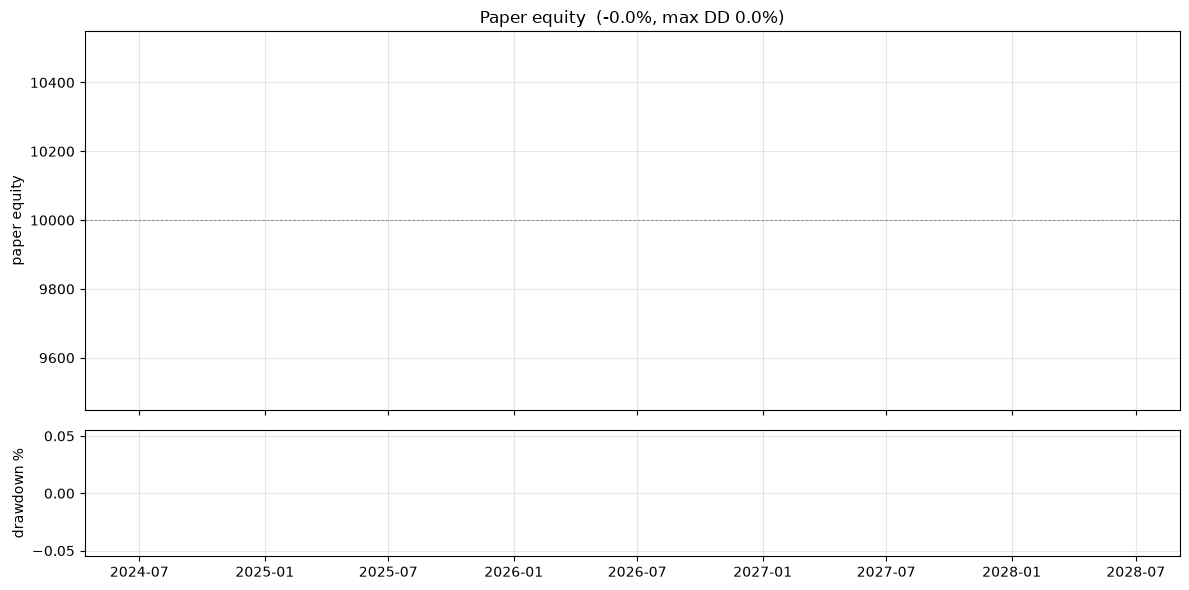

,bar_time,close,net_raw,vol_size,target_exposure,order_side,order_qty_btc,paper_equity,cum_return
0,2026-06-23 20:00:00,62470.7,0.25,0.356,0.089,BUY,0.014242,9998.67,-0.0001



next refresh ~ 00:00:15 local  (interrupt to stop)


In [ ]:
while True:
    try:
        pt.run_once(basket)        # processes the latest closed bar (appends a row if new)
    except Exception as e:
        print(f"[{dt.datetime.now():%H:%M:%S}] fetch/compute error: {e}")
    clear_output(wait=True)
    render()
    now = time.time(); nxt = (int(now//3600)+1)*3600 + 15
    print(f"\nnext refresh ~ {dt.datetime.fromtimestamp(nxt):%H:%M:%S} local  (interrupt to stop)")
    time.sleep(max(5, nxt - now))

## (optional) Just view the dashboard once, without the loop

In [ ]:
pt.run_once(basket); render()